In [ ]:
# ============================================================
# CELL 1 — IMPORTS AND PROJECT DIRECTORY SETUP
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths for structured project organization
BASE_DIR = "/content/Intel_MultiClass_Project"
DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

# Create directories if they do not exist
for folder in [DATA_DIR, PLOTS_DIR, RESULTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Project environment configured successfully!")
print(f"Data Directory:    {DATA_DIR}")
print(f"Plots Directory:   {PLOTS_DIR}")
print(f"Results Directory: {RESULTS_DIR}")

Project environment configured successfully!
Data Directory:    /content/Intel_MultiClass_Project/data
Plots Directory:   /content/Intel_MultiClass_Project/plots
Results Directory: /content/Intel_MultiClass_Project/results


In [ ]:
# ============================================================
# CELL 2 — KAGGLE DATASET DOWNLOAD AND EXTRACTION
# ============================================================

import os
import zipfile
from google.colab import files

# Upload your kaggle.json file
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Set up the Kaggle hidden directory
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

# Move file and adjust system permissions
if "kaggle.json" in uploaded:
    dest_path = os.path.join(kaggle_dir, "kaggle.json")
    os.rename("kaggle.json", dest_path)
    os.chmod(dest_path, 0o600)
    print("Kaggle API key configured successfully.\n")
else:
    raise FileNotFoundError("Could not find kaggle.json in the upload pool.")

# Download dataset via Kaggle CLI
print("Downloading Intel Image Classification dataset...")
os.system("kaggle datasets download -d puneet6060/intel-image-classification")

# Unzip and clean up
zip_file = "intel-image-classification.zip"
target_dir = "/content/Intel_MultiClass_Project/data"

if os.path.exists(zip_file):
    print(f"Extracting files to {target_dir}...")
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(target_dir)
    os.remove(zip_file)
    print("Extraction completed.")
else:
    print("Error: Zip file download failed.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle API key configured successfully.

Extracting files to /content/Intel_MultiClass_Project/data...
Extraction completed.


In [ ]:
# ============================================================
# CELL 3 — INSPECTING TRAINING DIRECTORIES
# ============================================================

import os
import pandas as pd

data_root = "/content/Intel_MultiClass_Project/data"
train_dir = os.path.join(data_root, "seg_train/seg_train")

# Fallback adjustment in case nested zip directory naming differs
if not os.path.exists(train_dir):
    train_dir = os.path.join(data_root, "seg_train")

print(f"Inspecting training directories in: {train_dir}\n")

stats = []
extensions = (".jpg", ".jpeg", ".png")

if os.path.exists(train_dir):
    for folder in sorted(os.listdir(train_dir)):
        folder_path = os.path.join(train_dir, folder)

        if os.path.isdir(folder_path):
            # Track valid images in each category subdirectory
            valid_files = [
                f
                for f in os.listdir(folder_path)
                if f.lower().endswith(extensions)
            ]
            stats.append({"Class Name": folder, "Image Count": len(valid_files)})

    # Compile and display the final distribution profile
    summary_df = pd.DataFrame(stats)
    print(summary_df.to_string(index=False))
else:
    print(f"Error: Specified directory context not found: {train_dir}")

Inspecting training directories in: /content/Intel_MultiClass_Project/data/seg_train/seg_train

Class Name  Image Count
 buildings         2191
    forest         2271
   glacier         2404
  mountain         2512
       sea         2274
    street         2382


In [ ]:
# ============================================================
# CELL 4 — MULTI-CLASS FEATURE EXTRACTION ENGINE
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy

train_dir = "/content/Intel_MultiClass_Project/data/seg_train/seg_train"
if not os.path.exists(train_dir):
    train_dir = "/content/Intel_MultiClass_Project/data/seg_train"

features_pool = []
extensions = (".jpg", ".jpeg", ".png")
MAX_IMAGES_PER_CLASS = 1000  # Enforces a clean, scaled-up balance across all 6 classes

print("Starting feature extraction across classes...")

for folder in sorted(os.listdir(train_dir)):
    folder_path = os.path.join(train_dir, folder)
    if not os.path.isdir(folder_path):
        continue

    print(f"Processing category: {folder}...")
    all_files = [f for f in os.listdir(folder_path) if f.lower().endswith(extensions)]
    # Clean selection cap to keep training sets perfectly balanced
    selected_files = all_files[:MAX_IMAGES_PER_CLASS]

    for filename in selected_files:
        img_path = os.path.join(folder_path, filename)

        # Load grayscale and color variants
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue

        # Standardize size for consistent edge density and matrix parsing
        img_bgr = cv2.resize(img_bgr, (150, 150))
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

        # 1. Grayscale Basic Metrics
        mean_intensity = np.mean(img_gray)
        std_intensity = np.std(img_gray)
        entropy_val = shannon_entropy(img_gray)

        # 2. Structural Edge Density
        edges = cv2.Canny(img_gray, 100, 200)
        edge_density = np.sum(edges > 0) / edges.size

        # 3. GLCM Texture Quantifiers (Distance=1, Angle=0)
        glcm = graycomatrix(img_gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        energy = graycoprops(glcm, 'energy')[0, 0]
        correlation = graycoprops(glcm, 'correlation')[0, 0]

        # 4. Color-Space Identifiers (Averages of Hue & Saturation channels)
        mean_hue = np.mean(img_hsv[:, :, 0])
        std_hue = np.std(img_hsv[:, :, 0])
        mean_saturation = np.mean(img_hsv[:, :, 1])

        features_pool.append({
            "Class_Label": folder,
            "Image_Path": img_path,
            "Mean_Intensity": mean_intensity,
            "Std_Intensity": std_intensity,
            "Entropy": entropy_val,
            "Edge_Density": edge_density,
            "GLCM_Contrast": contrast,
            "GLCM_Homogeneity": homogeneity,
            "GLCM_Energy": energy,
            "GLCM_Correlation": correlation,
            "Mean_Hue": mean_hue,
            "Std_Hue": std_hue,
            "Mean_Saturation": mean_saturation
        })

# Compile everything into a structured dataset
features_df = pd.DataFrame(features_pool)

# Save progress securely to your results directory
output_csv = "/content/Intel_MultiClass_Project/results/extracted_features.csv"
features_df.to_csv(output_csv, index=False)

print(f"\nExtraction finalized! Generated matrix shape: {features_df.shape}")
print(f"Data safely compiled and saved to: {output_csv}")

Starting feature extraction across classes...
Processing category: buildings...
Processing category: forest...
Processing category: glacier...
Processing category: mountain...
Processing category: sea...
Processing category: street...

Extraction finalized! Generated matrix shape: (6000, 13)
Data safely compiled and saved to: /content/Intel_MultiClass_Project/results/extracted_features.csv


In [ ]:
# ============================================================
# CELL 5 — MULTI-CLASS STATISTICAL VARIANCE TESTING
# ============================================================

import os
import pandas as pd
from scipy.stats import kruskal

csv_path = "/content/Intel_MultiClass_Project/results/extracted_features.csv"

# Load the extracted data to ensure independent execution capability
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError(f"Feature matrix not found at {csv_path}")

# Identify the handcrafted metric columns to test
ignore_cols = ["Class_Label", "Image_Path"]
feature_cols = [col for col in df.columns if col not in ignore_cols]

stats_results = []

print("Running Kruskal-Wallis H-Test across all 6 scene categories...\n")
print(f"{'Feature Name':<22} | {'H-Statistic':<12} | {'P-Value':<10} | {'Status'}")
print("-" * 65)

for col in feature_cols:
    # Group the specific feature values dynamically by their class label
    grouped_data = [group[col].values for name, group in df.groupby("Class_Label")]

    # Execute the non-parametric multi-class variance test
    h_stat, p_val = kruskal(*grouped_data)

    # Determine significance status (standard alpha threshold of 0.05)
    status = "Highly Significant" if p_val < 0.001 else ("Significant" if p_val < 0.05 else "Not Significant")

    stats_results.append({
        "Feature": col,
        "H-Statistic": h_stat,
        "P-Value": p_val,
        "Significance": status
    })

    print(f"{col:<22} | {h_stat:<12.4f} | {p_val:<10.3e} | {status}")

# Save the statistical evaluation summary table to the results directory
stats_df = pd.DataFrame(stats_results)
output_summary_path = "/content/Intel_MultiClass_Project/results/statistical_validation_summary.csv"
stats_df.to_csv(output_summary_path, index=False)

print(f"\nStatistical analysis finished. Summary table saved to: {output_summary_path}")

Running Kruskal-Wallis H-Test across all 6 scene categories...

Feature Name           | H-Statistic  | P-Value    | Status
-----------------------------------------------------------------
Mean_Intensity         | 1638.0541    | 0.000e+00  | Highly Significant
Std_Intensity          | 833.6357     | 6.111e-178 | Highly Significant
Entropy                | 178.8159     | 9.579e-37  | Highly Significant
Edge_Density           | 2520.3401    | 0.000e+00  | Highly Significant
GLCM_Contrast          | 3142.6430    | 0.000e+00  | Highly Significant
GLCM_Homogeneity       | 2704.0075    | 0.000e+00  | Highly Significant
GLCM_Energy            | 1655.1481    | 0.000e+00  | Highly Significant
GLCM_Correlation       | 3014.3307    | 0.000e+00  | Highly Significant
Mean_Hue               | 2065.2086    | 0.000e+00  | Highly Significant
Std_Hue                | 837.1875     | 1.042e-178 | Highly Significant
Mean_Saturation        | 759.2148     | 7.686e-162 | Highly Significant

Statistical analy

/tmp/ipykernel_1013/1531623098.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1013/1531623098.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Distribution boxplots generated successfully and saved to: /content/Intel_MultiClass_Project/plots/feature_distribution_boxplots.png


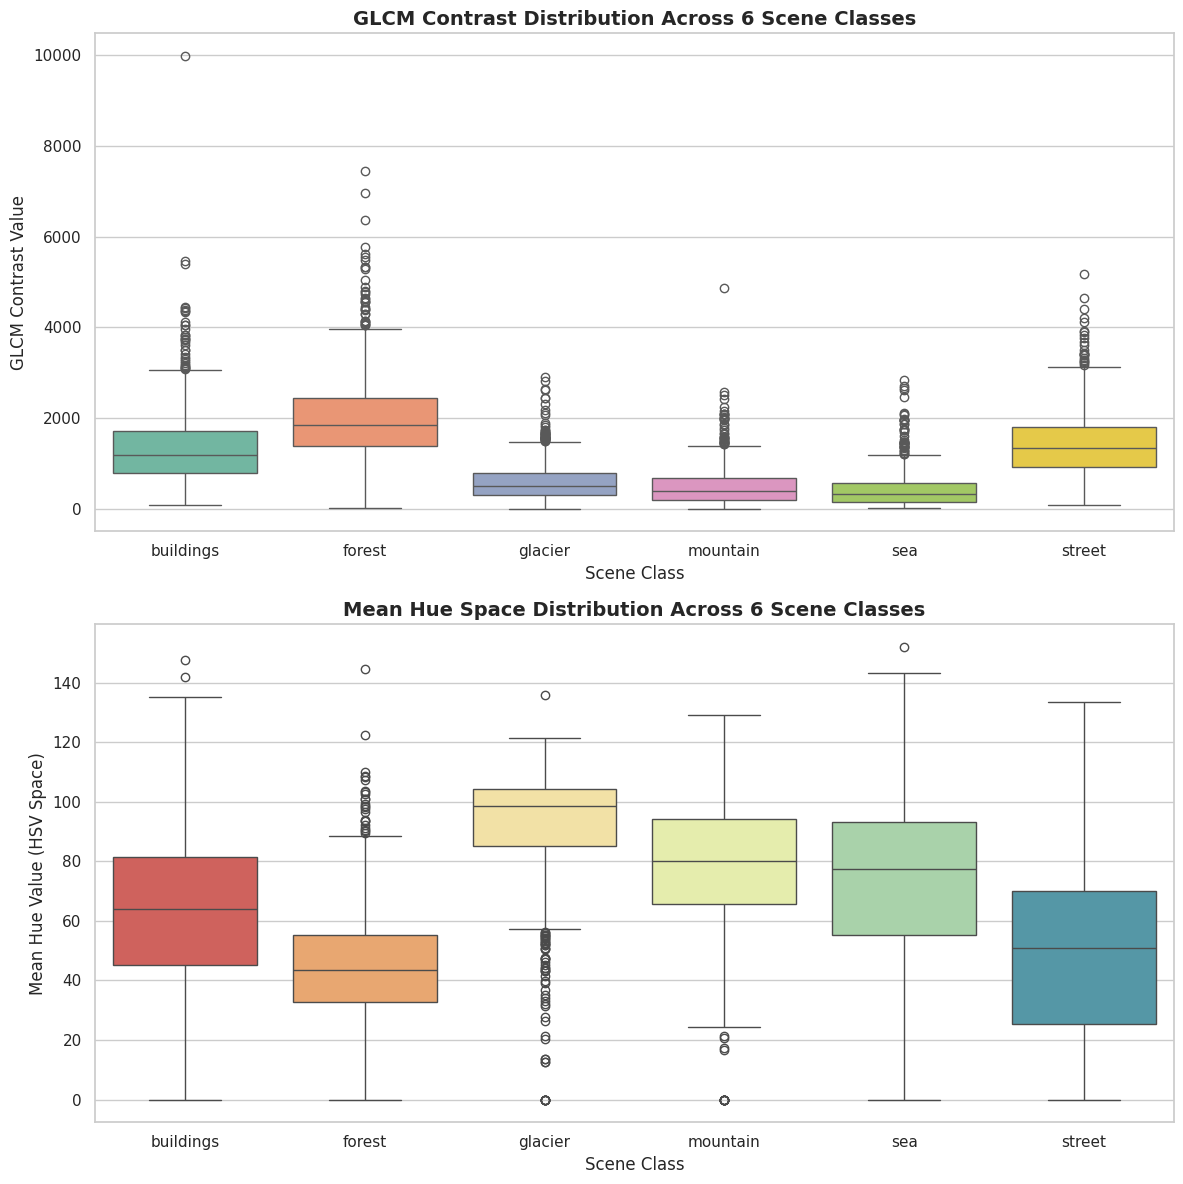

In [ ]:
# ============================================================
# CELL 6 — EXPLORATORY DISTRIBUTION VISUALIZATIONS
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csv_path = "/content/Intel_MultiClass_Project/results/extracted_features.csv"
plots_dir = "/content/Intel_MultiClass_Project/plots"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError(f"Missing feature data file: {csv_path}")

# Set up a clean, presentation-ready plotting canvas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# 1. Plotting the top texture feature distribution
sns.boxplot(
    ax=axes[0],
    x="Class_Label",
    y="GLCM_Contrast",
    data=df,
    palette="Set2"
)
axes[0].set_title("GLCM Contrast Distribution Across 6 Scene Classes", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Scene Class", fontsize=12)
axes[0].set_ylabel("GLCM Contrast Value", fontsize=12)

# 2. Plotting the top color feature distribution
sns.boxplot(
    ax=axes[1],
    x="Class_Label",
    y="Mean_Hue",
    data=df,
    palette="Spectral"
)
axes[1].set_title("Mean Hue Space Distribution Across 6 Scene Classes", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Scene Class", fontsize=12)
axes[1].set_ylabel("Mean Hue Value (HSV Space)", fontsize=12)

plt.tight_layout()

# Save the plot securely for your upcoming report
output_plot_path = os.path.join(plots_dir, "feature_distribution_boxplots.png")
plt.savefig(output_plot_path, dpi=300)
print(f"Distribution boxplots generated successfully and saved to: {output_plot_path}")

plt.show()

Running PCA dimensionality reduction...
Running t-SNE dimensionality reduction (this might take a moment)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



Projections completed successfully! Plot saved to: /content/Intel_MultiClass_Project/plots/dimensionality_reduction_clusters.png


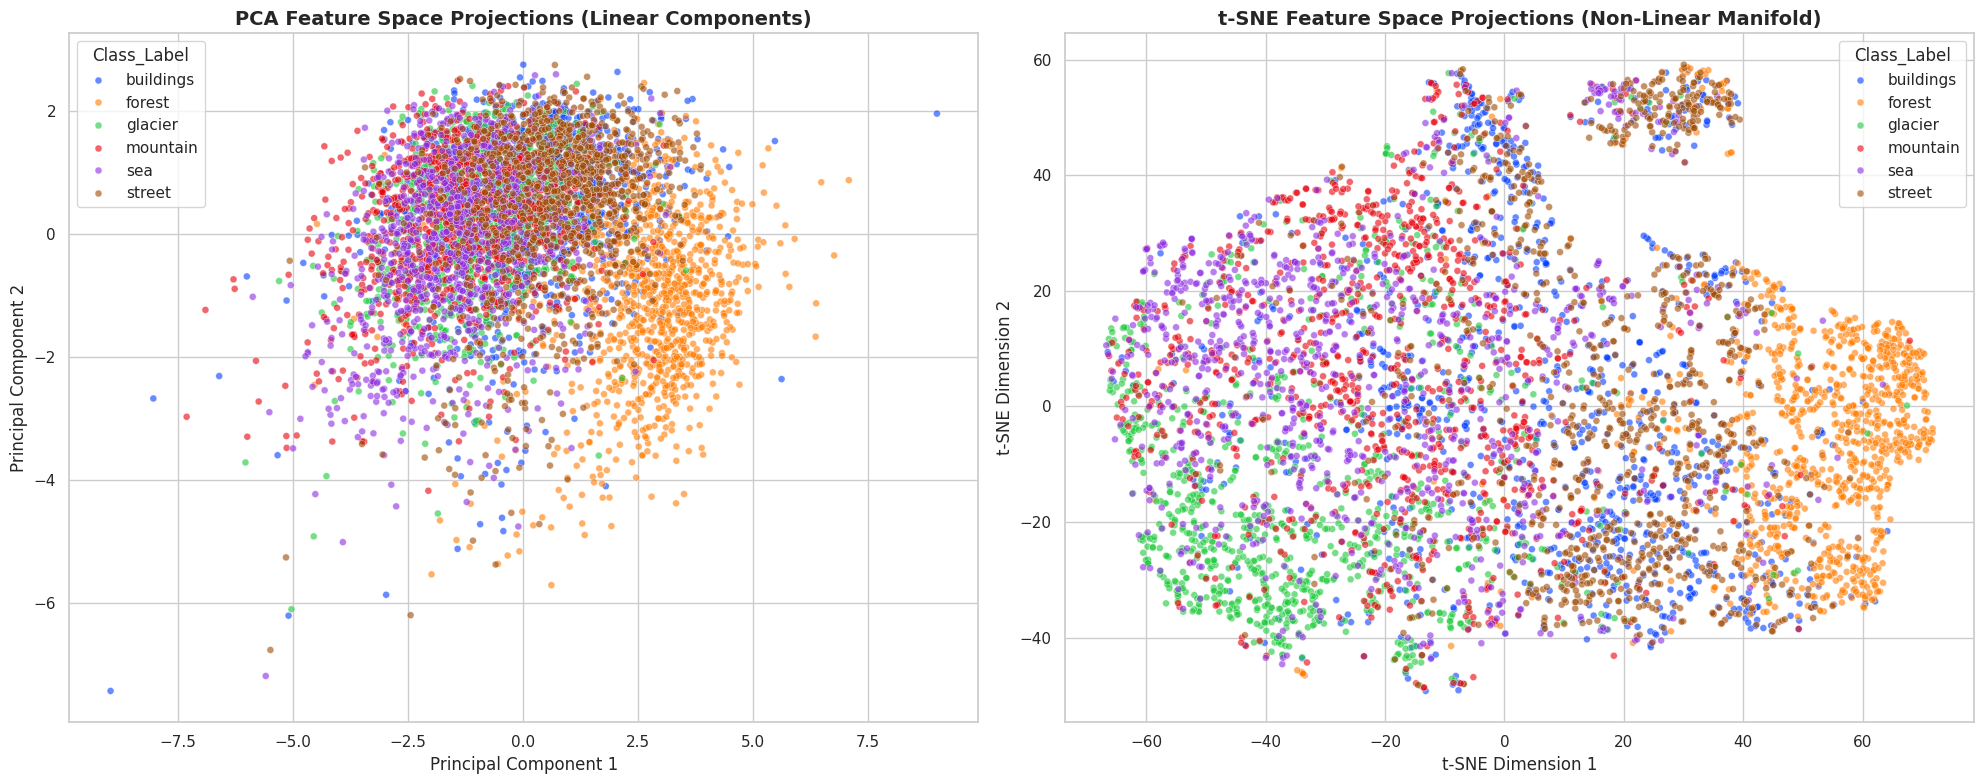

In [ ]:
# ============================================================
# CELL 7 — HIGH-DIMENSIONAL VISUALIZATIONS (PCA & T-SNE)
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

csv_path = "/content/Intel_MultiClass_Project/results/extracted_features.csv"
plots_dir = "/content/Intel_MultiClass_Project/plots"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError(f"Missing feature data file: {csv_path}")

# Separate features from target labels
X = df.drop(columns=["Class_Label", "Image_Path"])
y = df["Class_Label"]

# Standardize features (essential for variance-based reduction methods)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Running PCA dimensionality reduction...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Running t-SNE dimensionality reduction (this might take a moment)...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Create a clean plotting grid
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
palette = sns.color_palette("bright", len(y.unique()))

# 1. Plot PCA results
sns.scatterplot(
    ax=axes[0],
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y,
    palette=palette,
    alpha=0.6,
    s=25
)
axes[0].set_title("PCA Feature Space Projections (Linear Components)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Principal Component 1", fontsize=12)
axes[0].set_ylabel("Principal Component 2", fontsize=12)

# 2. Plot t-SNE results
sns.scatterplot(
    ax=axes[1],
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y,
    palette=palette,
    alpha=0.6,
    s=25
)
axes[1].set_title("t-SNE Feature Space Projections (Non-Linear Manifold)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("t-SNE Dimension 1", fontsize=12)
axes[1].set_ylabel("t-SNE Dimension 2", fontsize=12)

plt.tight_layout()

# Save clusters plot
output_cluster_path = os.path.join(plots_dir, "dimensionality_reduction_clusters.png")
plt.savefig(output_cluster_path, dpi=300)
print(f"\nProjections completed successfully! Plot saved to: {output_cluster_path}")

plt.show()

In [ ]:
# ============================================================
# CELL 8 — DATA PREPROCESSING AND STRATIFIED SPLITTING
# ============================================================

import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

csv_path = "/content/Intel_MultiClass_Project/results/extracted_features.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError(f"Missing feature data file: {csv_path}")

# 1. Isolate structural inputs (X) and string targets (y)
X = df.drop(columns=["Class_Label", "Image_Path"])
y = df["Class_Label"]

# 2. Convert text categories into numerical labels (0 to 5)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Print mapping sequence to track indices during evaluation later
print("Label Encoding Map:")
for index, class_name in enumerate(label_encoder.classes_):
    print(f"  Class {index} -> {class_name}")

# 3. Stratified Split: Enforces equal 6-class ratios across both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# 4. Feature Scaling: Adjusts variables to mean=0 and variance=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nData successfully prepared!")
print(f"Training feature set shape: {X_train_scaled.shape}")
print(f"Testing feature set shape:  {X_test_scaled.shape}")

Label Encoding Map:
  Class 0 -> buildings
  Class 1 -> forest
  Class 2 -> glacier
  Class 3 -> mountain
  Class 4 -> sea
  Class 5 -> street

Data successfully prepared!
Training feature set shape: (4800, 11)
Testing feature set shape:  (1200, 11)


In [ ]:
# ============================================================
# CELL 9 — RANDOM FOREST CLASSIFICATION & CROSS-VALIDATION
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

# Initialize the classifier with balanced parameters to prevent overfitting
# n_estimators=200 gives a stable ensemble of decision paths
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

# Enforce perfect 6-class balance across 5 independent verification folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Executing Stratified 5-Fold Cross-Validation on training features...")

# Calculate cross-validation performance across folds
cv_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

print("\n--- Cross-Validation Results ---")
for fold, score in enumerate(cv_scores, 1):
    print(f"  Fold {fold}: Accuracy = {score * 100:.2f}%")

mean_cv_acc = cv_scores.mean() * 100
print(f"\nMean CV Accuracy: {mean_cv_acc:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")

# Train the model on the full training set for a holdout test evaluation
print("\nTraining final Random Forest model on the entire training set...")
rf_model.fit(X_train_scaled, y_train)

# Evaluate performance on the untouched test split
y_pred_rf = rf_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred_rf) * 100
print(f"Holdout Test Set Accuracy: {test_accuracy:.2f}%")

Executing Stratified 5-Fold Cross-Validation on training features...

--- Cross-Validation Results ---
  Fold 1: Accuracy = 62.40%
  Fold 2: Accuracy = 59.48%
  Fold 3: Accuracy = 59.06%
  Fold 4: Accuracy = 61.35%
  Fold 5: Accuracy = 60.94%

Mean CV Accuracy: 60.65% (+/- 1.23%)

Training final Random Forest model on the entire training set...
Holdout Test Set Accuracy: 62.92%


--- Multi-Class Classification Performance Report ---
              precision    recall  f1-score   support

   buildings       0.52      0.51      0.52       200
      forest       0.86      0.89      0.87       200
     glacier       0.63      0.69      0.66       200
    mountain       0.56      0.50      0.53       200
         sea       0.56      0.51      0.53       200
      street       0.61      0.68      0.64       200

    accuracy                           0.63      1200
   macro avg       0.63      0.63      0.63      1200
weighted avg       0.63      0.63      0.63      1200


Evaluation metrics calculated! Confusion matrix saved to: /content/Intel_MultiClass_Project/plots/rf_confusion_matrix.png


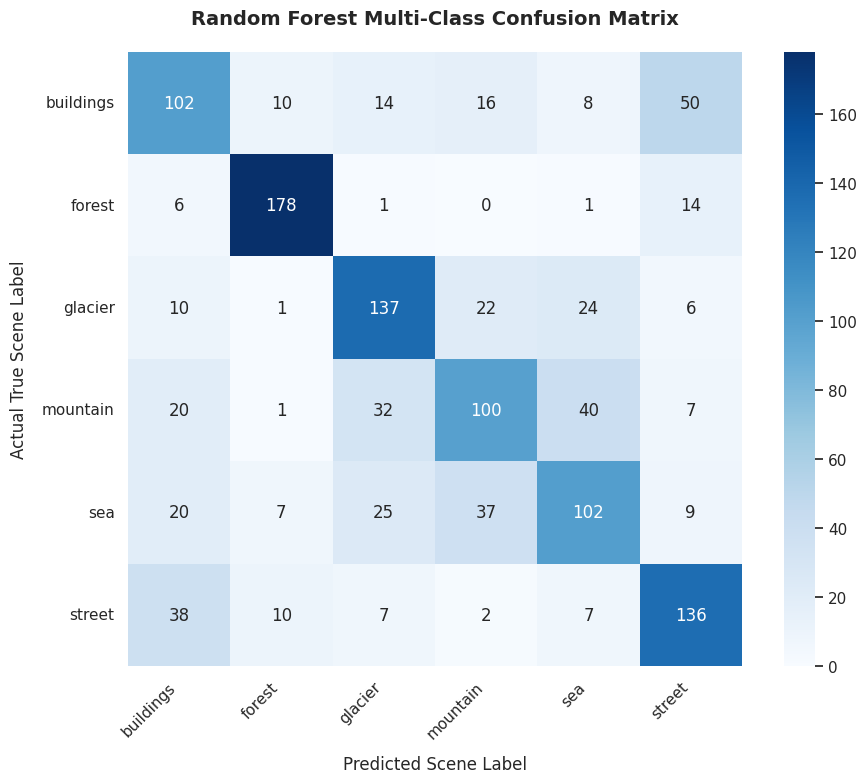

In [ ]:
# ============================================================
# CELL 10 — DETAILED MULTI-CLASS EVALUATION MATRIX
# ============================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

plots_dir = "/content/Intel_MultiClass_Project/plots"
results_dir = "/content/Intel_MultiClass_Project/results"

# Fetch the raw class string names from our label encoder mapping sequence
# class_names order: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
class_names = list(label_encoder.classes_)

print("--- Multi-Class Classification Performance Report ---")
# Generate precision, recall, and f1-score profiles for each distinct landscape
text_report = classification_report(y_test, y_pred_rf, target_names=class_names)
print(text_report)

# Save the raw text report for documentation purposes
with open(os.path.join(results_dir, "rf_classification_report.txt"), "w") as f:
    f.write(text_report)

# Compute the raw 6x6 confusion matrix values
cm = confusion_matrix(y_test, y_pred_rf)

# Build a clean, presentation-ready plotting canvas
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    square=True
)

plt.title("Random Forest Multi-Class Confusion Matrix", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Predicted Scene Label", fontsize=12, labelpad=10)
plt.ylabel("Actual True Scene Label", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save the visual heatmap matrix to the plots folder
output_matrix_path = os.path.join(plots_dir, "rf_confusion_matrix.png")
plt.savefig(output_matrix_path, dpi=300)
print(f"\nEvaluation metrics calculated! Confusion matrix saved to: {output_matrix_path}")

plt.show()

In [ ]:
# ============================================================
# CELL 11 — SUPPORT VECTOR MACHINE (SVM) CLASSIFICATION
# ============================================================

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

# Initialize SVM with a Radial Basis Function (RBF) kernel
# C=2.0 increases the penalty for misclassification to sharpen boundaries
svm_model = SVC(kernel="rbf", C=2.0, gamma="scale", random_state=42)

# Re-use our identical 5-fold stratified validation structure
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Executing Stratified 5-Fold Cross-Validation for SVM...")

cv_scores_svm = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

print("\n--- SVM Cross-Validation Results ---")
for fold, score in enumerate(cv_scores_svm, 1):
    print(f"  Fold {fold}: Accuracy = {score * 100:.2f}%")

mean_svm_acc = cv_scores_svm.mean() * 100
print(f"\nMean SVM CV Accuracy: {mean_svm_acc:.2f}% (+/- {cv_scores_svm.std() * 100:.2f}%)")

# Train the model on the full training pool
print("\nTraining final SVM model on the entire training set...")
svm_model.fit(X_train_scaled, y_train)

# Predict against the untouched testing splits
y_pred_svm = svm_model.predict(X_test_scaled)
svm_test_accuracy = accuracy_score(y_test, y_pred_svm) * 100
print(f"SVM Holdout Test Set Accuracy: {svm_test_accuracy:.2f}%")

Executing Stratified 5-Fold Cross-Validation for SVM...

--- SVM Cross-Validation Results ---
  Fold 1: Accuracy = 63.54%
  Fold 2: Accuracy = 61.98%
  Fold 3: Accuracy = 59.06%
  Fold 4: Accuracy = 63.96%
  Fold 5: Accuracy = 63.02%

Mean SVM CV Accuracy: 62.31% (+/- 1.75%)

Training final SVM model on the entire training set...
SVM Holdout Test Set Accuracy: 63.00%


In [ ]:
# ============================================================
# CELL 12 — LOGISTIC REGRESSION CLASSIFICATION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

# Initialize Logistic Regression with a multinomial (softmax) configuration
# max_iter is scaled up to 1000 to guarantee gradient descent convergence
log_reg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Re-use our standard 5-fold stratified validation layout
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Executing Stratified 5-Fold Cross-Validation for Logistic Regression...")

cv_scores_lr = cross_val_score(
    log_reg,
    X_train_scaled,
    y_train,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

print("\n--- Logistic Regression Cross-Validation Results ---")
for fold, score in enumerate(cv_scores_lr, 1):
    print(f"  Fold {fold}: Accuracy = {score * 100:.2f}%")

mean_lr_acc = cv_scores_lr.mean() * 100
print(f"\nMean Logistic Regression CV Accuracy: {mean_lr_acc:.2f}% (+/- {cv_scores_lr.std() * 100:.2f}%)")

# Train on the entire training subset
print("\nTraining final Logistic Regression model on the entire training set...")
log_reg.fit(X_train_scaled, y_train)

# Evaluate performance on the holdout split
y_pred_lr = log_reg.predict(X_test_scaled)
lr_test_accuracy = accuracy_score(y_test, y_pred_lr) * 100
print(f"Logistic Regression Holdout Test Set Accuracy: {lr_test_accuracy:.2f}%")

Executing Stratified 5-Fold Cross-Validation for Logistic Regression...

--- Logistic Regression Cross-Validation Results ---
  Fold 1: Accuracy = 59.48%
  Fold 2: Accuracy = 58.96%
  Fold 3: Accuracy = 57.08%
  Fold 4: Accuracy = 59.27%
  Fold 5: Accuracy = 58.96%

Mean Logistic Regression CV Accuracy: 58.75% (+/- 0.86%)

Training final Logistic Regression model on the entire training set...
Logistic Regression Holdout Test Set Accuracy: 59.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# ============================================================
# CELL 13 — SUMMARY AND FINAL MODEL COMPARISON MATRIX
# ============================================================

import os
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

results_dir = "/content/Intel_MultiClass_Project/results"

# 1. Compute weighted metric profiles for Random Forest
rf_metrics = precision_recall_fscore_support(y_test, y_pred_rf, average="weighted")
# 2. Compute weighted metric profiles for SVM
svm_metrics = precision_recall_fscore_support(y_test, y_pred_svm, average="weighted")
# 3. Compute weighted metric profiles for Logistic Regression
lr_metrics = precision_recall_fscore_support(y_test, y_pred_lr, average="weighted")

# 4. Consolidate all metrics into a clean presentation DataFrame
comparison_data = {
    "Model": ["Logistic Regression", "Random Forest", "Support Vector Machine (SVM)"],
    "CV Accuracy (%)": [mean_lr_acc, mean_cv_acc, mean_svm_acc],
    "Test Accuracy (%)": [lr_test_accuracy, test_accuracy, svm_test_accuracy],
    "Precision (%)": [lr_metrics[0] * 100, rf_metrics[0] * 100, svm_metrics[0] * 100],
    "Recall (%)": [lr_metrics[1] * 100, rf_metrics[1] * 100, svm_metrics[1] * 100],
    "F1-Score (%)": [lr_metrics[2] * 100, rf_metrics[2] * 100, svm_metrics[2] * 100]
}

comparison_df = pd.DataFrame(comparison_data)

# Round the values to 2 decimal places for clean academic formatting
metrics_cols = ["CV Accuracy (%)", "Test Accuracy (%)", "Precision (%)", "Recall (%)", "F1-Score (%)"]
comparison_df[metrics_cols] = comparison_df[metrics_cols].round(2)

print("--- Final Multi-Class Model Comparison Matrix ---")
print(comparison_df.to_string(index=False))

# Save the structured dataframe as a final summary file
output_csv_path = os.path.join(results_dir, "Final_MultiClass_Model_Comparison.csv")
comparison_df.to_csv(output_csv_path, index=False)

print(f"\nSummary table saved successfully to: {output_csv_path}")

--- Final Multi-Class Model Comparison Matrix ---
                       Model  CV Accuracy (%)  Test Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
         Logistic Regression            58.75              59.00          58.16       59.00         58.42
               Random Forest            60.65              62.92          62.54       62.92         62.63
Support Vector Machine (SVM)            62.31              63.00          62.88       63.00         62.75

Summary table saved successfully to: /content/Intel_MultiClass_Project/results/Final_MultiClass_Model_Comparison.csv


Comparison chart generated successfully and saved to: /content/Intel_MultiClass_Project/plots/model_performance_comparison.png


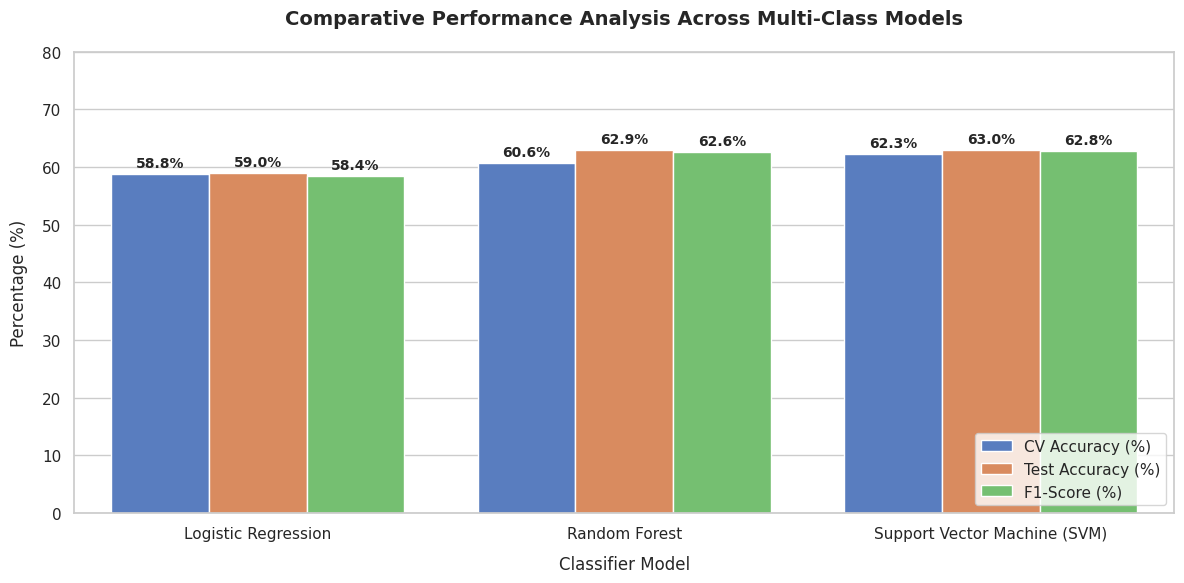

In [ ]:
# ============================================================
# CELL 14 — VISUALIZING MODEL PERFORMANCE COMPARISONS
# ============================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns

plots_dir = "/content/Intel_MultiClass_Project/plots"

# Set up a clean, structured plotting environment
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Melt the dataframe to make it compatible with a side-by-side seaborn barplot
melted_df = pd.melt(
    comparison_df,
    id_vars=["Model"],
    value_vars=["CV Accuracy (%)", "Test Accuracy (%)", "F1-Score (%)"],
    var_name="Metric",
    value_name="Percentage"
)

# Generate a grouped bar chart
ax = sns.barplot(
    data=melted_df,
    x="Model",
    y="Percentage",
    hue="Metric",
    palette="muted"
)

# Add numerical value labels on top of each bar for absolute clarity
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.1f}%",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

plt.title("Comparative Performance Analysis Across Multi-Class Models", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Classifier Model", fontsize=12, labelpad=10)
plt.ylabel("Percentage (%)", fontsize=12, labelpad=10)
plt.ylim(0, 80)  # Leaves uniform overhead room for the data text labels
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()

# Save the final comparison plot securely
output_comparison_plot = os.path.join(plots_dir, "model_performance_comparison.png")
plt.savefig(output_comparison_plot, dpi=300)
print(f"Comparison chart generated successfully and saved to: {output_comparison_plot}")

plt.show()